In [37]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import seaborn as sns

In [38]:
df=pd. read_csv('50_Startups.csv')
df

,R&D Spend,Administration,Marketing Spend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94
5,131876.90,99814.71,362861.36,New York,156991.12
6,134615.46,147198.87,127716.82,California,156122.51
7,130298.13,145530.06,323876.68,Florida,155752.60
8,120542.52,148718.95,311613.29,New York,152211.77
9,123334.88,108679.17,304981.62,California,149759.96


In [39]:
df.isnull().sum()

R&D Spend          0
Administration     0
Marketing Spend    0
State              0
Profit             0
dtype: int64

<Axes: xlabel='Administration', ylabel='Profit'>

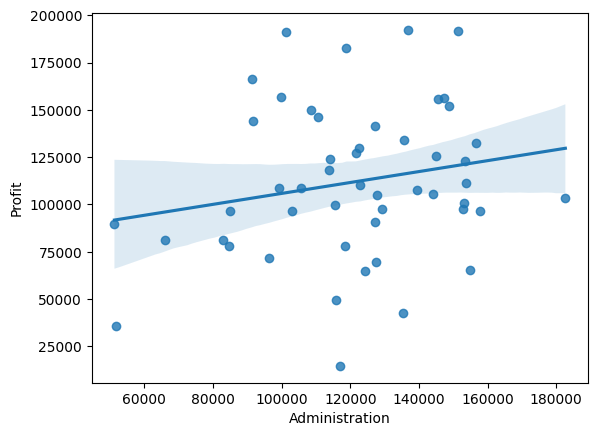

In [40]:
sns.regplot(df,x='Administration',y='Profit')

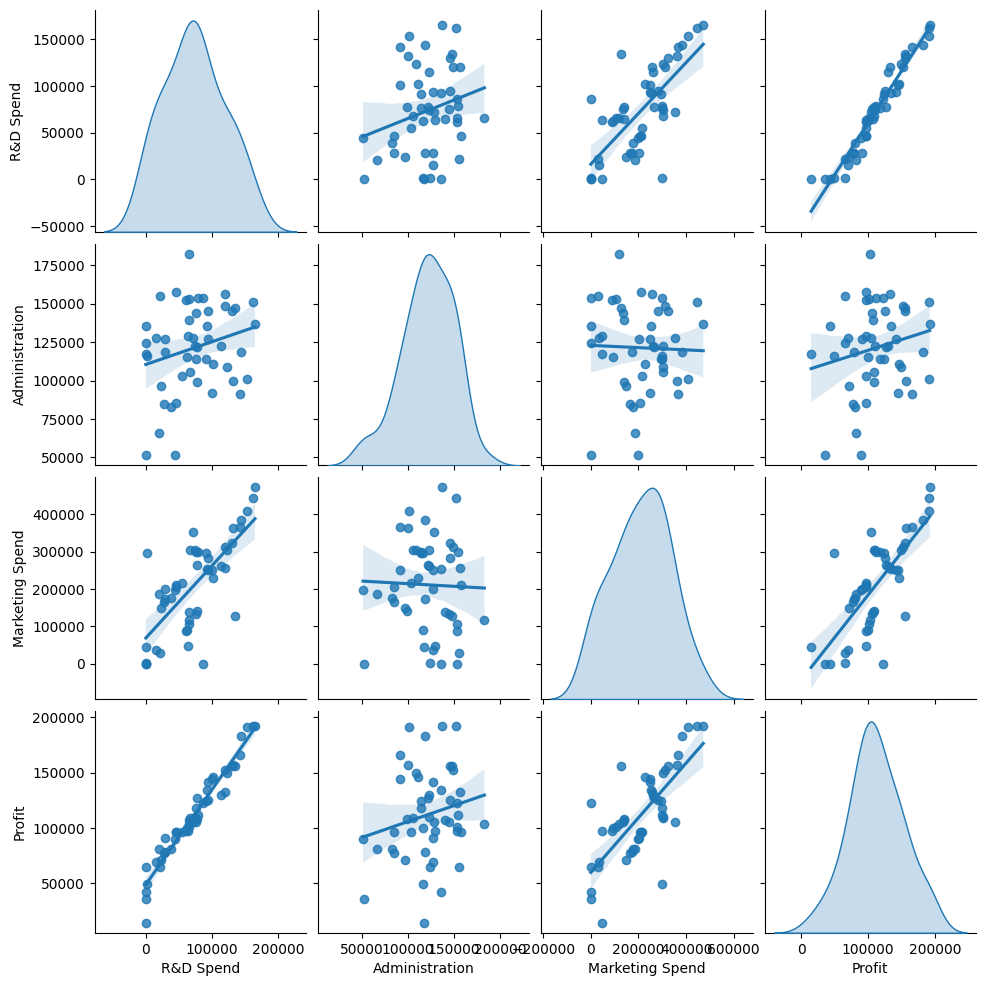

In [41]:
sns.pairplot(df, kind = 'reg', diag_kind='kde')

In [42]:
X = df.drop(columns=['Profit'])
y = df['Profit']

In [43]:
print(X)

    R&D Spend  Administration  Marketing Spend       State
0   165349.20       136897.80        471784.10    New York
1   162597.70       151377.59        443898.53  California
2   153441.51       101145.55        407934.54     Florida
3   144372.41       118671.85        383199.62    New York
4   142107.34        91391.77        366168.42     Florida
5   131876.90        99814.71        362861.36    New York
6   134615.46       147198.87        127716.82  California
7   130298.13       145530.06        323876.68     Florida
8   120542.52       148718.95        311613.29    New York
9   123334.88       108679.17        304981.62  California
10  101913.08       110594.11        229160.95     Florida
11  100671.96        91790.61        249744.55  California
12   93863.75       127320.38        249839.44     Florida
13   91992.39       135495.07        252664.93  California
14  119943.24       156547.42        256512.92     Florida
15  114523.61       122616.84        261776.23    New Yo

In [ ]:
Xtrain, Xtest, ytrain, ytest = train_test_split(X, y, test_size= 0.2, random_state=0)
''' 
'''

Column Selection

In [45]:
cat_cols = X.select_dtypes(include=['object']).columns
num_cols = X.select_dtypes(include=['number']).columns

In [46]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

Pipeline

In [47]:
cat_pipe = Pipeline(
    steps=[
        ('encoder', OneHotEncoder(drop= 'first'))
    ]
)

In [48]:
num_pipe = Pipeline(
    steps=[
        ('scaler', StandardScaler())
    ]
)

In [49]:
preprocesser = ColumnTransformer(
    transformers=[
        ('cat', cat_pipe, cat_cols),
        ('num', num_pipe, num_cols)
    ]
)

In [50]:
model = Pipeline(steps=[
    ('preprocessor', preprocesser),
    ('lr', LinearRegression())
])

In [51]:
model.fit(Xtrain, ytrain)

,steps,"[('preprocessor', ...), ('lr', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [ ]:
#dump is used to save the model and load is used to load the model

from joblib import dump, load

dump(model, 'model/multiple_linear_regression.pkl')
print("Model saved successfully.")


Model saved successfully.


In [ ]:
from joblib import dump , load #dump is used to save the model and load is used to load the model 
with open('model/multiple_linear_regression.pkl', 'wb') as f:
     dump(model, f) #dumping the model into the file 
     print('Model dumped successfully')